# CosMx - Human Breast FFPE Multiomic dataset


This script focuses on initial data loading to QC for the dataset shared at [cosmx-human-multiomic-breast-dataset](https://brukerspatialbiology.com/products/cosmx-spatial-molecular-imager/ffpe-dataset/cosmx-human-multiomic-breast-dataset/). 


In [1]:
## sbatch --mem=180G -p tier2q  ./launch_jupyter_conda.sh /gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/conda_envs/scverse_spatial

## LIBRARIES
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from scipy.sparse import csr_matrix

/gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/conda_envs/scverse_spatial/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Input data: Flatfiles

The Standard processed output for CosMx are flatfiles. A given folder is created for each slide, containing information about counts, cells metadata and transcripts information. 

- **SLIDE_exprMat_file.csv** — Counts matrix. Rows are cells (identified by cell_ID + fov), columns are genes. 

- **SLIDE_metadata_file.csv** — Per-cell metadata. Contains spatial coordinates in in FOV-local space (CenterX_local_px, CenterY_local_px) and at the slide level, as global pixels ( CenterX_global_px, CenterY_global_px). It contains other attributes as cell area, aspect ratio, mean DAPI intensity, and other morphology metrics. One row per cell.

- **SLIDE_fov_positions_file.csv** — FOV-level layout. Maps each FOV number to its position in the slide. One row per FOV, defined by their top-left corner coordinate in both global pixels and millimiters. 

- **SLIDE_polygons.csv** or **SLIDE_tx_file.csv** — The transcript-level file. Every single detected transcript with its x/y coordinates and gene assignment. Only needed if you want subcellular/transcript-level analysis, these files are the largest ones in the collection.


In this example, our dataset for Breast Cancer includes 384 FOVs. 

In [ ]:
## ── PATHS AND PARAMETERS ───────────────────────────────────────────────────────

sample_id = "BreastCancer"                 # used in output filenames, keep also the same name set for the slide. 

data_dir = Path("./data/CosMx_Human_breast/Flatfiles_RNA/flatFiles/BreastCancer")
out_dir   = Path("./CosMx/results")          # where checkpoints are saved

## Check data_dir exists. 
assert data_dir.is_dir(), f"Data directory {data_dir} does not exist. Please check the path."

out_dir.mkdir(parents=True, exist_ok=True)

# ── Expected flat file names (standard Nanostring export) ────────────────────
# Adjust glob patterns if your prefix differs
expr_file     = next(data_dir.glob("*exprMat_file.csv.gz"))
meta_file     = next(data_dir.glob("*metadata_file.csv.gz"))
fov_file      = next(data_dir.glob("*fov_positions_file.csv.gz"))

print("Expression matrix :", expr_file.name)
print("Cell metadata      :", meta_file.name)
print("FOV positions      :", fov_file.name)

Expression matrix : BreastCancer_exprMat_file.csv.gz
Cell metadata      : BreastCancer_metadata_file.csv.gz
FOV positions      : BreastCancer_fov_positions_file.csv.gz


### AnnData

In addition to counts and metadata, we also set up the spatial component, this allow us to use `squidpy` down the line. 

In [3]:
## Create AnnData from flat files. 

## 1. Read expression matrix (cells × genes, with system columns)
expr = pd.read_csv(expr_file, engine="pyarrow")          # or engine="c" with dtype

# 2. Pivot to cell × gene (drop system columns first)
system_cols = ["fov", "cell_ID", "cell"]  # adjust to your file
gene_cols = [c for c in expr.columns if c not in system_cols]
# X = csr_matrix(expr[gene_cols].values)
# Convert to sparse BEFORE loading metadata — halves peak RAM
X = csr_matrix(expr[gene_cols].to_numpy(dtype=np.float32))
del expr   # free the dense DataFrame immediately
import gc; gc.collect()

# 3. Read metadata
meta = pd.read_csv(meta_file, engine="pyarrow")

# 4. Build AnnData
adata = sc.AnnData(X=X, obs=meta, var=pd.DataFrame(index=gene_cols))

# 5. Assign spatial coords from metadata (CosMx uses CenterX_global_px etc.)
adata.obsm["spatial"] = meta[["CenterX_global_px", "CenterY_global_px"]].values

del meta; gc.collect()

/gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/conda_envs/scverse_spatial/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


0

In [5]:
## Given this is a spatial dataset, we need to add some minimal spatial metadata to adata.uns["spatial"] for compatibility with Squidpy's spatial plotting functions.

adata.uns["spatial"] = {
    sample_id: {
        "images": {},
        "scalefactors": {"spot_diameter_fullres": 1, "tissue_hires_scalef": 1},
    }
}

adata.uns["spatial"][sample_id]["use_as_default"] = True

In [7]:
print(adata)
print("\nobs columns :", adata.obs.columns.tolist())
print("obsm keys   :", list(adata.obsm.keys()))

## Save initial AnnData object (optional checkpoint)
adata.write(out_dir / f"{sample_id}_adata_initial.h5ad", compression="gzip")

## Read again to check it was saved correctly (optional)
# adata = sc.read_h5ad(out_dir / f"{sample_id}_adata_initial.h5ad")

AnnData object with n_obs × n_vars = 152451 × 20385
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'cell_id', 'version', 'dualfiles', 'Run_name', 'Run_Tissue_name', 'ISH.concentration', 'CosMx', 'tissue', 'Panel', 'assay_type', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 

In [8]:
# Verify global spatial coordinates are stored correctly — critical for Giotto handoff later
assert "spatial" in adata.obsm, "Global spatial coords missing from obsm['spatial']"
print("Spatial coord range:")
print("  x:", adata.obsm["spatial"][:, 0].min(), "→", adata.obsm["spatial"][:, 0].max())
print("  y:", adata.obsm["spatial"][:, 1].min(), "→", adata.obsm["spatial"][:, 1].max())

Spatial coord range:
  x: 4529.0 → 59823.0
  y: 85274.0 → 123555.0


## 2. Dataset basics


In [9]:
print(f"Cells   : {adata.n_obs:,}")
print(f"Genes   : {adata.n_vars:,}")
print("\nFirst few obs columns:")
adata.obs.head()

Cells   : 152,451
Genes   : 20,385

First few obs columns:


,fov,Area,AspectRatio,CenterX_local_px,CenterY_local_px,Width,Height,Mean.PanCK,Max.PanCK,Mean.CD68,...,falsecode_quantile_0.75,falsecode_quantile_0.8,falsecode_quantile_0.85,falsecode_quantile_0.9,falsecode_quantile_0.95,falsecode_quantile_0.99,nCount_falsecode,nFeature_falsecode,Area.um2,cell
0,33,3502,0.77,2053,178,78,60,210.2,4568,237.7,...,0,0.0,1.0,1.0,1.0,2.0,1,1,50.665205,c_1_33_1
1,33,10219,0.92,4180,631,150,138,549.8,3164,340.4,...,0,0.0,1.0,1.0,1.0,2.0,3,2,147.843441,c_1_33_2
2,33,7688,0.88,4006,727,100,114,1338.9,5428,4481.8,...,0,0.0,1.0,1.0,1.0,2.0,0,0,111.226184,c_1_33_3
3,33,3808,0.88,4081,718,74,84,626.6,2860,450.8,...,0,0.0,1.0,1.0,1.0,2.0,0,0,55.092262,c_1_33_4
4,33,5067,1.00,3945,757,88,88,972.9,5108,375.1,...,0,0.0,1.0,1.0,1.0,2.0,0,0,73.306852,c_1_33_5


In [10]:
# Check for negative-probe / blank columns — CosMx includes these for QC
neg_probes = [g for g in adata.var_names if "NegPrb" in g or "Blank" in g or "neg" in g.lower()]
print(f"Negative probes / blanks found: {len(neg_probes)}")
print(neg_probes)

Negative probes / blanks found: 51
['NEGR1', 'Negative1', 'Negative10', 'Negative11', 'Negative12', 'Negative13', 'Negative14', 'Negative15', 'Negative16', 'Negative17', 'Negative18', 'Negative19', 'Negative2', 'Negative20', 'Negative21', 'Negative22', 'Negative23', 'Negative24', 'Negative25', 'Negative26', 'Negative27', 'Negative28', 'Negative29', 'Negative3', 'Negative30', 'Negative31', 'Negative32', 'Negative33', 'Negative34', 'Negative35', 'Negative36', 'Negative37', 'Negative38', 'Negative39', 'Negative4', 'Negative40', 'Negative41', 'Negative42', 'Negative43', 'Negative44', 'Negative45', 'Negative46', 'Negative47', 'Negative48', 'Negative49', 'Negative5', 'Negative50', 'Negative6', 'Negative7', 'Negative8', 'Negative9']


## 3. QC metrics


For CosMx, an additional layer to understand noise is based on negative probes. In adittion we also might have information on cell area and nucleus area. 

The key QC metrics will be: 

* Number of transcripts per cell

* Number of genes detected per cell

* Percentage of counts related to negative probes.

* Cell area

* Nucleus area


Negative probes, similarly to GeoMx are orthogonal to any gene probe, so we expect no signal from them, when there is some signal from them it can be derived from autflourescence, non-specific hybridization or optical noise. 


In [11]:
# Flag negative probes so we can use them as a noise proxy
adata.var["negative_probe"] = adata.var_names.isin(neg_probes)

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["negative_probe"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

# Key metrics now in adata.obs:
#   total_counts             — total transcripts per cell
#   n_genes_by_counts        — number of detected genes
#   pct_counts_negative_probe — % counts from negative probes (noise indicator)
adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_negative_probe"]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])



,total_counts,n_genes_by_counts,pct_counts_negative_probe
count,152451.000000,152451.000000,152451.000000
mean,2012.339478,1345.317099,0.085220
std,1949.312622,1139.598245,0.158064
min,5.000000,2.000000,0.000000
5%,158.000000,123.000000,0.000000
25%,617.000000,476.000000,0.000000
50%,1332.000000,989.000000,0.054377
75%,2837.000000,1956.000000,0.117371
95%,5987.000000,3640.000000,0.285714
max,25774.000000,11148.000000,16.666668


In [12]:
## Cell Aspect metrics

# Also pull area and aspect ratio from metadata if available — useful for debris filtering
area_col = [c for c in adata.obs.columns if "area" in c.lower()]
print("Area-related columns:", area_col)


adata.obs[area_col].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])

Area-related columns: ['Area', 'NucArea', 'Area.um2']


,Area,NucArea,Area.um2
count,152451.000000,152451.000000,152451.000000
mean,6778.817791,2165.418600,98.072585
std,3797.156861,1739.730864,54.935389
min,680.000000,0.000000,9.837904
5%,2416.000000,0.000000,34.953494
25%,4189.000000,964.000000,60.604382
50%,5966.000000,1824.000000,86.313139
75%,8406.000000,3016.000000,121.613853
95%,13856.000000,5428.000000,200.461759
max,67525.000000,25124.000000,976.918324


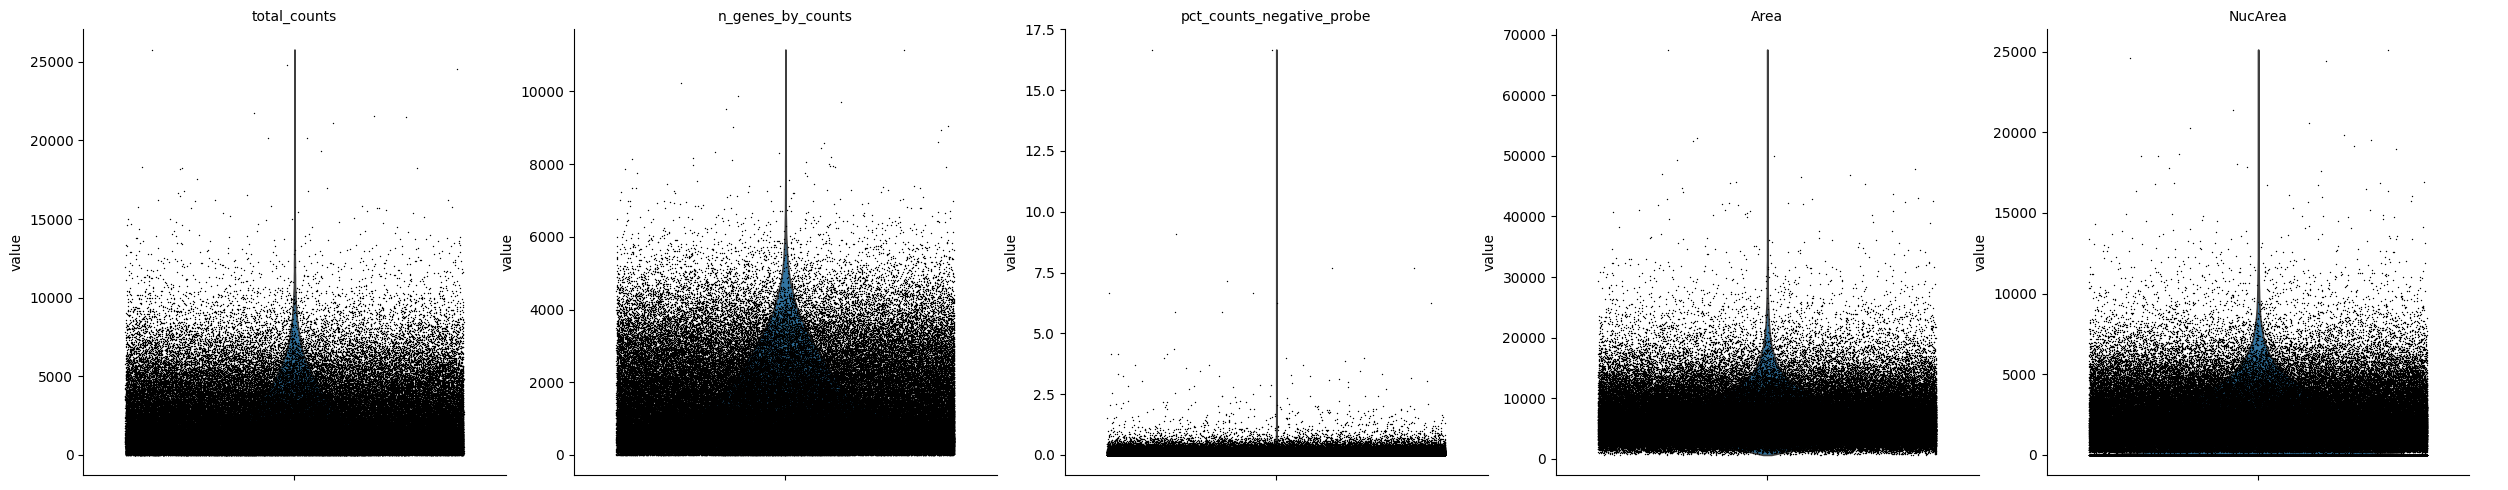

In [13]:
sc.pl.violin(
    adata,
    ["total_counts", "n_genes_by_counts", "pct_counts_negative_probe", 'Area', 'NucArea'],
    jitter=0.4,
    multi_panel=True,
)

Text(0.5, 1.0, 'Percentage of Counts from Negative Probes')

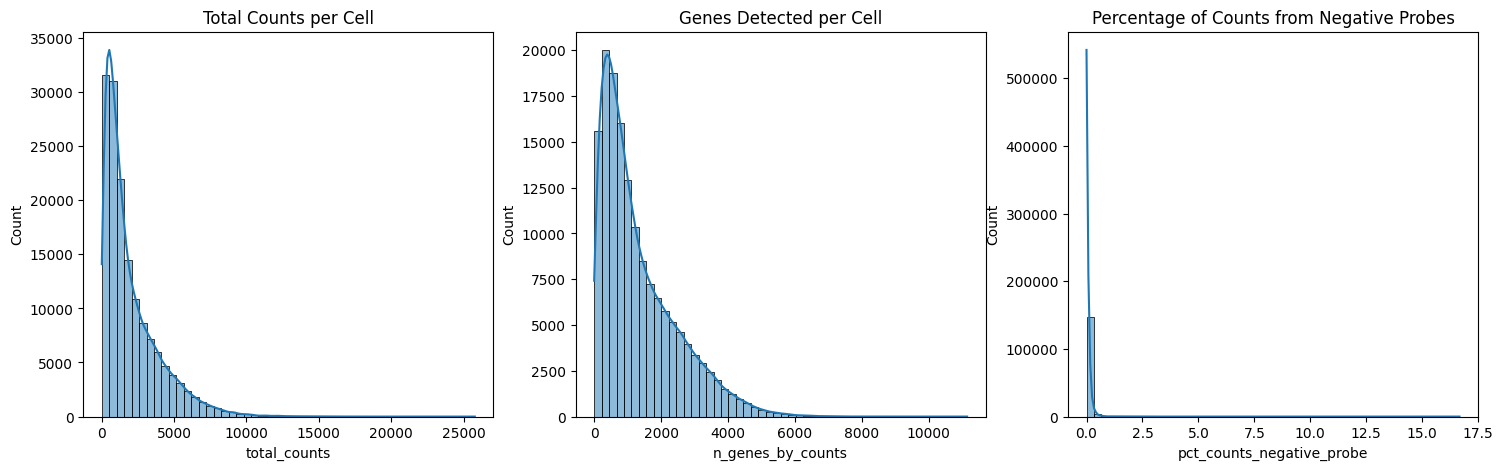

In [16]:
## Histogram of QC metrics

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(adata.obs["total_counts"], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Total Counts per Cell")
sns.histplot(adata.obs["n_genes_by_counts"], bins=50, ax=axes[1], kde=True)
axes[1].set_title("Genes Detected per Cell")
sns.histplot(adata.obs["pct_counts_negative_probe"], bins=50, ax=axes[2], kde=True)
axes[2].set_title("Percentage of Counts from Negative Probes")

Text(0.5, 1.0, 'Cell Area (μm²)')

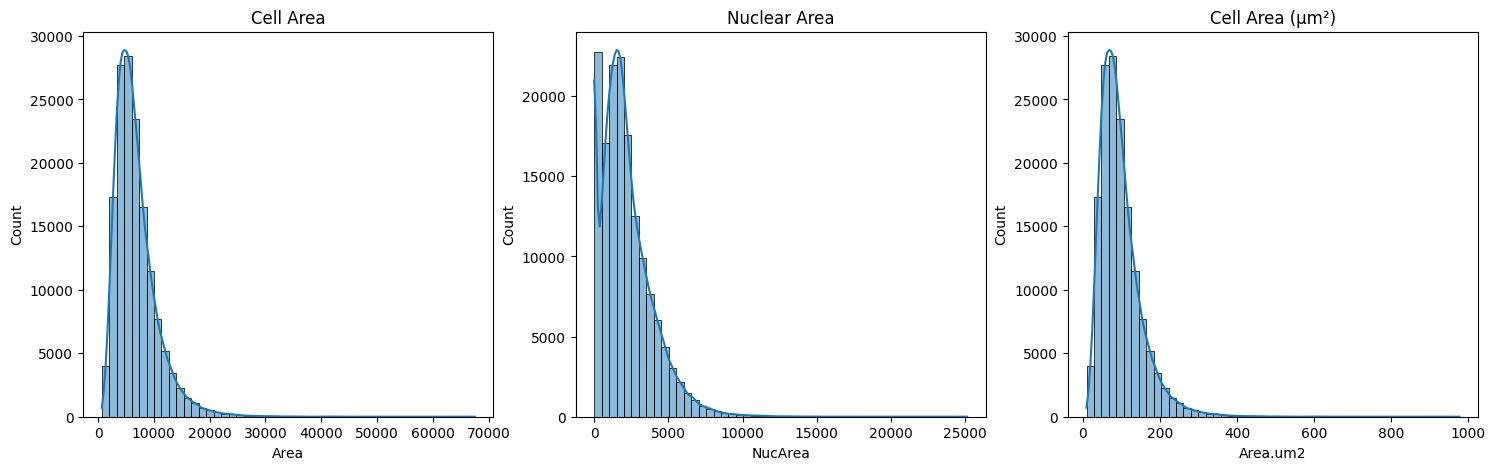

In [18]:
## Cell Aspect metrics: 'Area', 'NucArea', 'Area.um2'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(adata.obs["Area"], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Cell Area")
sns.histplot(adata.obs["NucArea"], bins=50, ax=axes[1], kde=True)
axes[1].set_title("Nuclear Area")
sns.histplot(adata.obs["Area.um2"], bins=50, ax=axes[2], kde=True)
axes[2].set_title("Cell Area (μm²)")

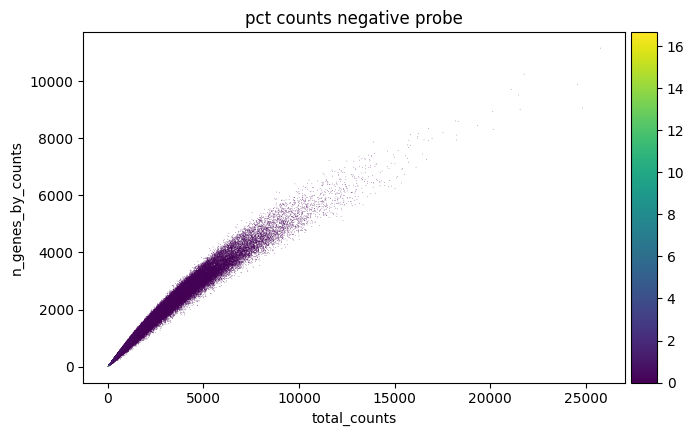

In [20]:
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_negative_probe",
)

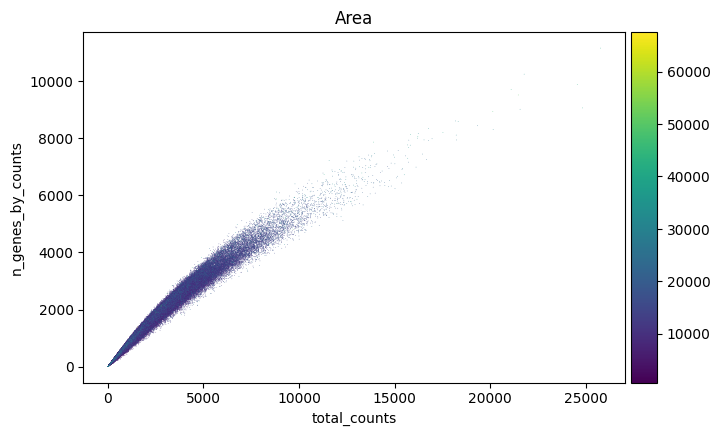

In [41]:
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="Area",
)

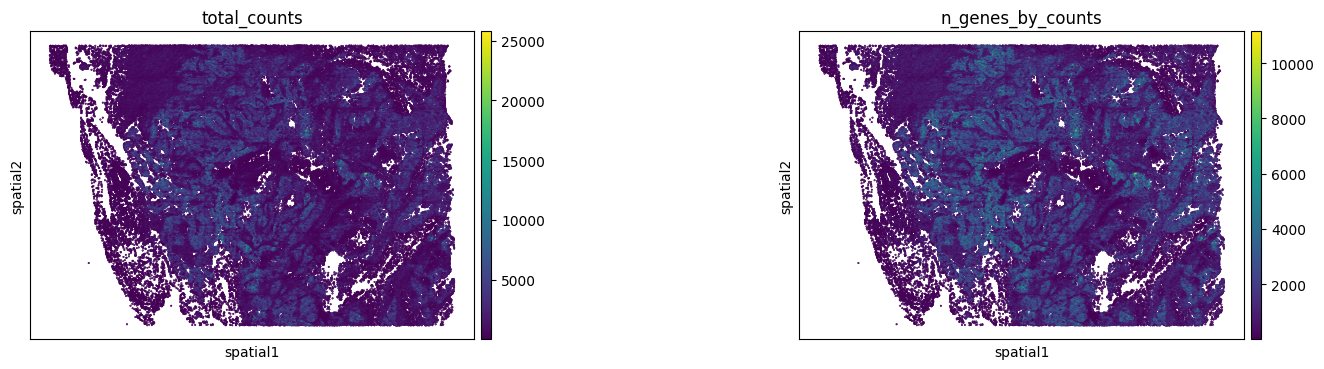

In [30]:
sq.pl.spatial_scatter(
    adata,
    color=["total_counts", "n_genes_by_counts"],
    shape=None,
    size=0.5,
    figsize=(8, 4),
)

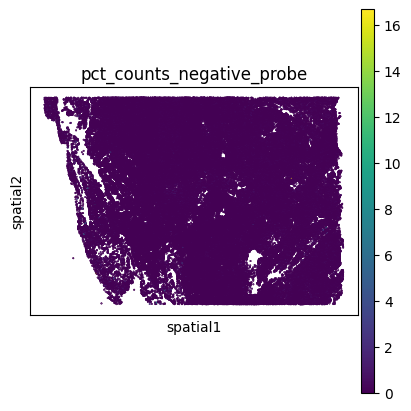

In [31]:
sq.pl.spatial_scatter(
    adata,
    color=["pct_counts_negative_probe"],
    shape=None,
    size=0.5,
    figsize=(4, 4),
)

### FOV statistics

Since the data is processed per FOV, it is helpful to check the average percent of negative probes and average counts as a way to identify potential FOVs with issues. 

Text(0.5, 1.0, 'Average Total Counts per FOV')

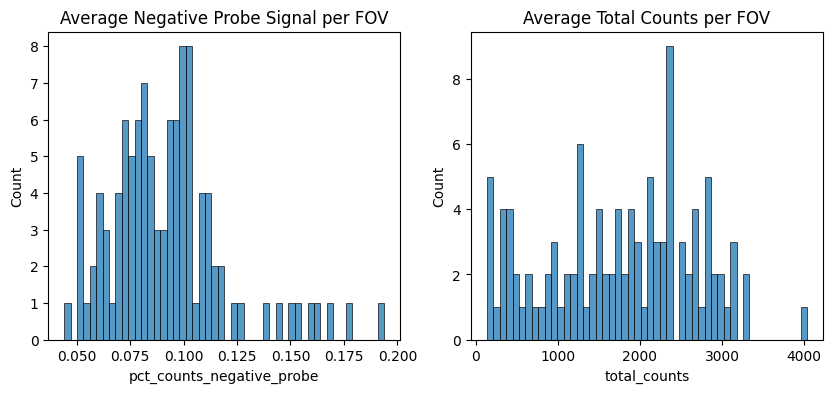

In [60]:
## Obtain average negative probe signal per FOV to set a more informed threshold for filtering.
fov_neg_signal = adata.obs.groupby("fov")["pct_counts_negative_probe"].mean()
fov_counts = adata.obs.groupby("fov")["total_counts"].mean()


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(fov_neg_signal, bins=50, ax=axes[0])
axes[0].set_title("Average Negative Probe Signal per FOV")


sns.histplot(fov_counts, bins=50, ax=axes[1])
axes[1].set_title("Average Total Counts per FOV")

## 4. Filtering

Compared to other single-cell datasets, CosMx uses a probe-based method, so we cannot apply the same thresholding for number of genes detected. This will also be dependent on the number of genes in the panel and how well it matches your tissue of interest. 
The goal is to omit empty segments. 
The area filter needs to be informed in the biology: Large cells like neurons or hepatocytes will have high counts compared to other cell types. 

**Panel size threshold suggestions:**

* 1k - At least 20 counts and 10 genes. 

* 6k - At least 50 counts, and 50 genes. 

* Whole Transcriptome (~18k) - In this case, we can try more strict filtering, with counts > 200, and genes > 100. 

After we are satisfied with our filtering, we can remove the negative probes information. 



In [14]:
# ── Thresholds — adjust after inspecting plots ───────────────────────────────
MIN_COUNTS      = 200       # cells with fewer total transcripts → likely empty
MAX_COUNTS      = 7500     # very high counts → possible doublets or debris
MIN_GENES       = 100        # minimum detected genes
MAX_NEG_PCT     = 1.0      # max % counts from negative probes
MIN_AREA      = 50       # Only if area column is present — adjust based on distribution, e.g. remove very small debris
MAX_AREA      = 15000       # Merged cells, adjust based on distribution.

print(f"Cells before filtering: {adata.n_obs:,}")

# Apply filters
mask = (
    (adata.obs["total_counts"]             >= MIN_COUNTS) &
    (adata.obs["total_counts"]             <= MAX_COUNTS) &
    (adata.obs["n_genes_by_counts"]        >= MIN_GENES)  &
    (adata.obs["pct_counts_negative_probe"]<= MAX_NEG_PCT) &
    (adata.obs["Area"]                     >= MIN_AREA) &
    (adata.obs["Area"]                     <= MAX_AREA)
)

## Print how many cells are removed by each filter individually (for diagnostics)
print(f"Cells removed by total_counts < {MIN_COUNTS} : {(adata.obs["total_counts"]< MIN_COUNTS).sum()}")
print(f"Cells removed by total_counts > {MAX_COUNTS} : {(adata.obs["total_counts"]> MAX_COUNTS).sum()}")
print(f"Cells removed by n_genes_by_counts < {MIN_GENES} : {(adata.obs["n_genes_by_counts"]< MIN_GENES).sum()}")
print(f"Cells removed by pct_counts_negative_probe > {MAX_NEG_PCT} : {(adata.obs["pct_counts_negative_probe"]> MAX_NEG_PCT).sum()}")
print(f"Cells removed by Area < {MIN_AREA} : {(adata.obs["Area"]< MIN_AREA).sum()}")
print(f"Cells removed by Area > {MAX_AREA} : {(adata.obs["Area"]> MAX_AREA).sum()}")


mask.sum()


Cells before filtering: 152,451
Cells removed by total_counts < 200 : 9953
Cells removed by total_counts > 7500 : 3103
Cells removed by n_genes_by_counts < 100 : 6038
Cells removed by pct_counts_negative_probe > 1.0 : 373
Cells removed by Area < 50 : 0
Cells removed by Area > 15000 : 5542


np.int64(135695)

In [15]:
adata = adata[mask].copy()
print(f"Cells after filtering : {adata.n_obs:,}")
print(f"Removed               : {mask.sum() - adata.n_obs:,}  "
      f"({(~mask).mean()*100:.1f}%)")

Cells after filtering : 135,695
Removed               : 0  (11.0%)


In [16]:
# Remove negative probes from the feature set before downstream analysis
adata = adata[:, ~adata.var["negative_probe"]].copy()
print(f"Genes after removing negative probes: {adata.n_vars}")

Genes after removing negative probes: 20334


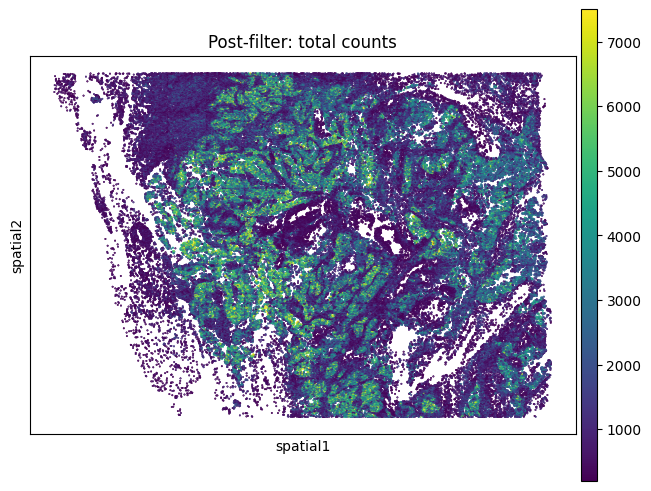

In [17]:
sq.pl.spatial_scatter(
    adata,
    color="total_counts",
    shape=None,
    size=0.5,
    title="Post-filter: total counts",
)

In [18]:
out_path = out_dir / f"{sample_id}_filtered.h5ad"
adata.write_h5ad(out_path)
print(f"Saved: {out_path}")
print(adata)

Saved: CosMx/results/BreastCancer/BreastCancer_filtered.h5ad
AnnData object with n_obs × n_vars = 135695 × 20334
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'cell_id', 'version', 'dualfiles', 'Run_name', 'Run_Tissue_name', 'ISH.concentration', 'CosMx', 'tissue', 'Panel', 'assay_type', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprob